<!-- DEA Notebook Header -->
<div style="font-family:'Segoe UI',Roboto,sans-serif; line-height:1.6; color:CanvasText; padding:32px;">

<img src="https://raw.githubusercontent.com/GeoscienceAustralia/dea-notebooks/stable/Supplementary_data/dea_logo_wide.jpg" alt="DEA Notebooks logo" style="width:86.5%;">

<h1>Introduction to DEA Fractional Cover</h1>

<p>
🔎 Visit <a href="https://knowledge.dea.ga.gov.au">DEA's Knowledge Hub</a> for detailed technical information about the datasets and concepts used in this notebook.
</p>

<p>
<span style="display:inline-block; font-size:12px; background:rgba(59,130,246,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🟡 Intermediate</span>
<span style="display:inline-block; font-size:12px; background:rgba(16,185,129,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">⚡ Time to complete: ~25 mins</span>
<span style="display:inline-block; font-size:12px; background:rgba(107,114,128,0.15); border-radius:12px; padding:3px 10px; margin-right:6px;">🗓️ Updated: 2025-12</span>
</p>

<!-- Products - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(59,130,246,0.08); border:1px solid rgb(59,130,246); border-radius:8px; max-width:85%;">
<b>📦 Products used</b><br>
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-fractional-cover-landsat/">ga_ls_fc_3</a>, 
<a href="https://knowledge.dea.ga.gov.au/data/product/dea-water-observations-landsat/">ga_ls_wo_3</a>
</div>


<!-- How to run - REQUIRED -->
<div style="margin-bottom:12px; padding:12px; background:rgba(16,185,129,0.1); border:1px solid rgb(16,185,129); border-radius:8px; max-width:85%;">
<b>🚀 How you can run this notebook</b><br>

- <b>DEA Sandbox:</b> Eligible users can sign up for the <a href="https://knowledge.dea.ga.gov.au/guides/setup/Sandbox/sandbox/">DEA Sandbox</a> that provides free compute and a managed Python environment.

- <b>Personal computer:</b> This notebook loads DEA data using <code>odc-stac</code>. Data streams via the internet, so can be run locally after installing the required <a href="https://pypi.org/project/dea-tools/">DEA Tools</a> Python package, e.g. <code>pip install dea-tools[notebooks]</code>.

- <b>Run this notebook online:</b> Click on the badge below to launch a GitHub Codespaces instance to run the notebook from your browser. See this <a href="">wiki page</a> for more information.

  <a href="https://codespaces.new/GeoscienceAustralia/dea-notebooks/tree/template?quickstart=1" target="_blank">
    <img src="https://img.shields.io/badge/Codespaces-Open-blue?logo=github" alt="Open in GitHub Codespaces" style="height:25px;">
  </a>
</div>

</div>

## Background
Fractional cover data can be used to identify large scale patterns and trends and inform evidence based decision making and policy on topics including wind and water erosion risk, soil carbon dynamics, land management practices and rangeland condition.

This information is used by policy agencies, natural and agricultural land resource managers, and scientists to monitor land conditions over large areas over long time frames.

### What this product offers
[Fractional Cover (FC)](https://knowledge.dea.ga.gov.au/data/product/dea-fractional-cover-landsat), developed by the [Joint Remote Sensing Research Program](https://www.jrsrp.org.au), is a measurement that splits the landscape into three parts, or fractions:

* green (photosynthetic) vegetation such as leaves, grass, and growing crops
* brown (non-photosynthetic) vegetation like branches, dry grass or hay, and dead leaf litter
* bare ground (soil or rock)

DEA uses Fractional Cover to characterise every 30 m square of Australia for any point in time from 1987 to today.

### Applications
Fractional cover provides valuable information for a range of environmental and agricultural applications, including:

* soil erosion monitoring
* land surface process modelling
* land management practices (e.g. crop rotation, stubble management, rangeland management)
* vegetation studies
* fuel load estimation
* ecosystem modelling
* land cover mapping

### Publications
* Lymburner, L., 2021. Geoscience Australia Landsat Fractional Cover Collection 3. Geoscience Australia, Canberra. https://pid.geoscience.gov.au/dataset/ga/145498

* Scarth, P., Roder, A., Schmidt, M., 2010. Tracking grazing pressure and climate interaction - the role of Landsat fractional cover in time series analysis. Proceedings of the 15th Australasian Remote Sensing & Photogrammetry Conference. http://dx.doi.org/10.6084/M9.FIGSHARE.94250

## Description
This notebook will demonstrate how to load DEA Fractional Cover using the Digital Earth Australia datacube. 
Topics covered include:

1. [Inspecting the available Fractional Cover product and bands](#Available-products)
2. [Loading DEA Fractional Cover for a specific time and location](#Loading-data)
3. [Plotting fractional cover as false colour images](#Plotting-data)
4. [Inspecting unmixing error outputs to better understand data quality](#Loading-WO-data)
5. [Advanced: Using Water Observations data to mask out poor quality Fractional Cover data](#Advanced) 
6. [Advanced: Tracking changes in green and brown vegetation cover over time](#Calculating-average-fractional-cover-over-time)


***

## Setup

### Load packages
Import Python packages that are used for the analysis.

In [62]:
import pprint
import yaml
import urllib.request
import odc.stac
import pystac_client
import numpy as np
import matplotlib.pyplot as plt

from odc.geo import BoundingBox

from dea_tools.datahandling import stac_collections, stac_assets, dea_stac_cfg
from dea_tools.plotting import rgb, plot_wo

### Connect to DEA's STAC API

This allows us to search for data using DEA's STAC API (refer to the [SpatioTemporal Asset Catalogue guide](https://knowledge.dea.ga.gov.au/guides/setup/gis/stac/) or [Loading data with STAC notebook](../Beginners_guide/04a_Loading_data_STAC.ipynb) for details).

To load data, we must also configure access to DEA's Amazon S3 buckets using `odc.stac.configure_s3_access`.
If launching a Dask client (e.g. `dea_tools.dask.create_local_dask_cluster()`), this is done automatically.

In [63]:
# Configure data access
odc.stac.configure_s3_access(cloud_defaults=True, aws_unsigned=True)

# Connect to DEA STAC API
catalog = pystac_client.Client.open("https://explorer.dea.ga.gov.au/stac")

## Analysis

### Available products
We can use the `stac_collections` function to inspect DEA Fractional Cover products that are available in DEA's STAC catalog:

In [64]:
products = ["ga_ls_fc_3"]
stac_collections(catalog, products)

,description,bbox,start_date,end_date,license
product,,,,,
ga_ls_fc_3,Geoscience Australia Landsat Fractional Cover ...,"70.09, -55.59, 169.90, -7.63",1986-08-15,2025-11-27,CC-BY-4.0


### Available bands (assets)
We can inspect the data available for the DEA Fractional Cover product using the `stac_assets` function.

The table below lists each of the measurements available (also known as STAC "assets") for `ga_ls_fc_3`, which represent unique data variables that provide information about the vegetation and bare soil cover in each pixel:

* `pv`: The fractional cover of green vegetation 
* `npv`:  The fractional cover of non-green vegetation
* `bs`: The fractional cover of bare soil 
* `ue`: The fractional cover unmixing error

In [65]:
stac_assets(catalog, products="ga_ls_fc_3")

roles band_names nodata dtype
product    asset                              
ga_ls_fc_3 bs     data         bs             
           pv     data         pv             
           ue     data         ue             
           npv    data        npv

## Loading data
Now that we know what products and measurements (assets) are available for the product, we can load data from DEA using `odc-stac`.

In the example below, we will load data from 1993 over the Walkerie area in South Australia.

<div class="alert alert-info">
    
**Note:** For more details about loading data, refer to the [Introduction to loading data with STAC](../Beginners_guide/04a_Loading_data_STAC.ipynb) notebook.
    
</div>


In [66]:
# Compute the bounding box object for the area of interest

bbox = BoundingBox(
    left=139.83315,
    bottom=-34.22099,
    right=140.05151,
    top=-34.06813,
    crs="EPSG:4326"
)

bbox.explore()

In [67]:
# Search the STAC catalog for all items matching the query
query = catalog.search(
    bbox=bbox,
    collections="ga_ls_fc_3",
    datetime="1993-10-15/1993-11-20")


# Convert the retrieved items to a list
items = list(query.items())
print(f"Found: {len(items)} STAC items.")

Found: 8 STAC items.


We also need to collect some extra metadata for the Fractional Cover product. We can do this with a custom function, `stac_cfg` from `dea-tools`. We will then pass this extra metadata to `odc-stac` when we load the data.

In [68]:
fc_config = dea_stac_cfg(products="ga_ls_fc_3")
pprint.pprint(fc_config)

{'ga_ls_fc_3': {'aliases': {'bare': 'bs',
                            'dead_veg': 'npv',
                            'err': 'ue',
                            'green_veg': 'pv'},
                'assets': {'bs': {'data_type': 'uint8',
                                  'nodata': 255,
                                  'unit': 'percent'},
                           'npv': {'data_type': 'uint8',
                                   'nodata': 255,
                                   'unit': 'percent'},
                           'pv': {'data_type': 'uint8',
                                  'nodata': 255,
                                  'unit': 'percent'},
                           'ue': {'data_type': 'uint8',
                                  'nodata': 255,
                                  'unit': '1'}}}}


In [69]:
# Load the data
fc = odc.stac.load(
    items,
    bands=["pv", "npv", "bs", "ue"],
    bbox=bbox,
    stac_cfg=fc_config,
    crs="EPSG:32754",
    groupby="solar_day"
)

We can now view the data that we loaded.
The measurements listed under `Data variables` should match the bands we requested above.

In [70]:
fc

<xarray.Dataset> Size: 6MB
Dimensions:      (y: 573, x: 677, time: 4)
Coordinates:
  * y            (y) float64 5kB 6.23e+06 6.23e+06 ... 6.213e+06 6.213e+06
  * x            (x) float64 5kB 3.923e+05 3.924e+05 ... 4.126e+05 4.126e+05
  * time         (time) datetime64[ns] 32B 1993-10-21T23:55:17.672013 ... 199...
    spatial_ref  int32 4B 32754
Data variables:
    pv           (time, y, x) uint8 2MB 52 51 53 47 38 32 ... 33 30 32 30 32 23
    npv          (time, y, x) uint8 2MB 27 25 31 35 37 41 ... 54 51 53 48 52 51
    bs           (time, y, x) uint8 2MB 20 22 14 17 24 26 ... 12 18 14 21 15 25
    ue           (time, y, x) uint8 2MB 12 13 11 10 9 9 9 ... 13 12 13 13 12 11

## Plotting data
<img align="right" src="../Supplementary_data/DEA_Fractional_Cover/fc_legend.jpg" alt="Fractional cover ternary diagram">

We can plot each FC variable in our dataset (i.e. `['bs', 'pv', 'npv']`) using the `rgb` function. 
This will create a false colour view of the data where shades of green, blue and red represent varying proportions of vegetation and bare soil cover:

* Green: green vegetation (`pv`)
* Blue: brown (i.e. 'non-green') vegetation (`npv`)
* Red: bare soil (`bs`)

The resulting images show agricultural fields containing high proportions of green vegetation cover, surrounded by areas dominated by brown vegetation and bare soil. Note that the third image contains dense clouds which are erroneously mapped as non-growing vegetation.

<div class="alert alert-info">
    
**Note:** Fractional cover values range between 0 and 100%, but due to model uncertainties and the limitations of the training data, some areas may show cover values in excess of 100%. 
These areas can either be excluded or treated as equivalent to 100%.
    
</div>

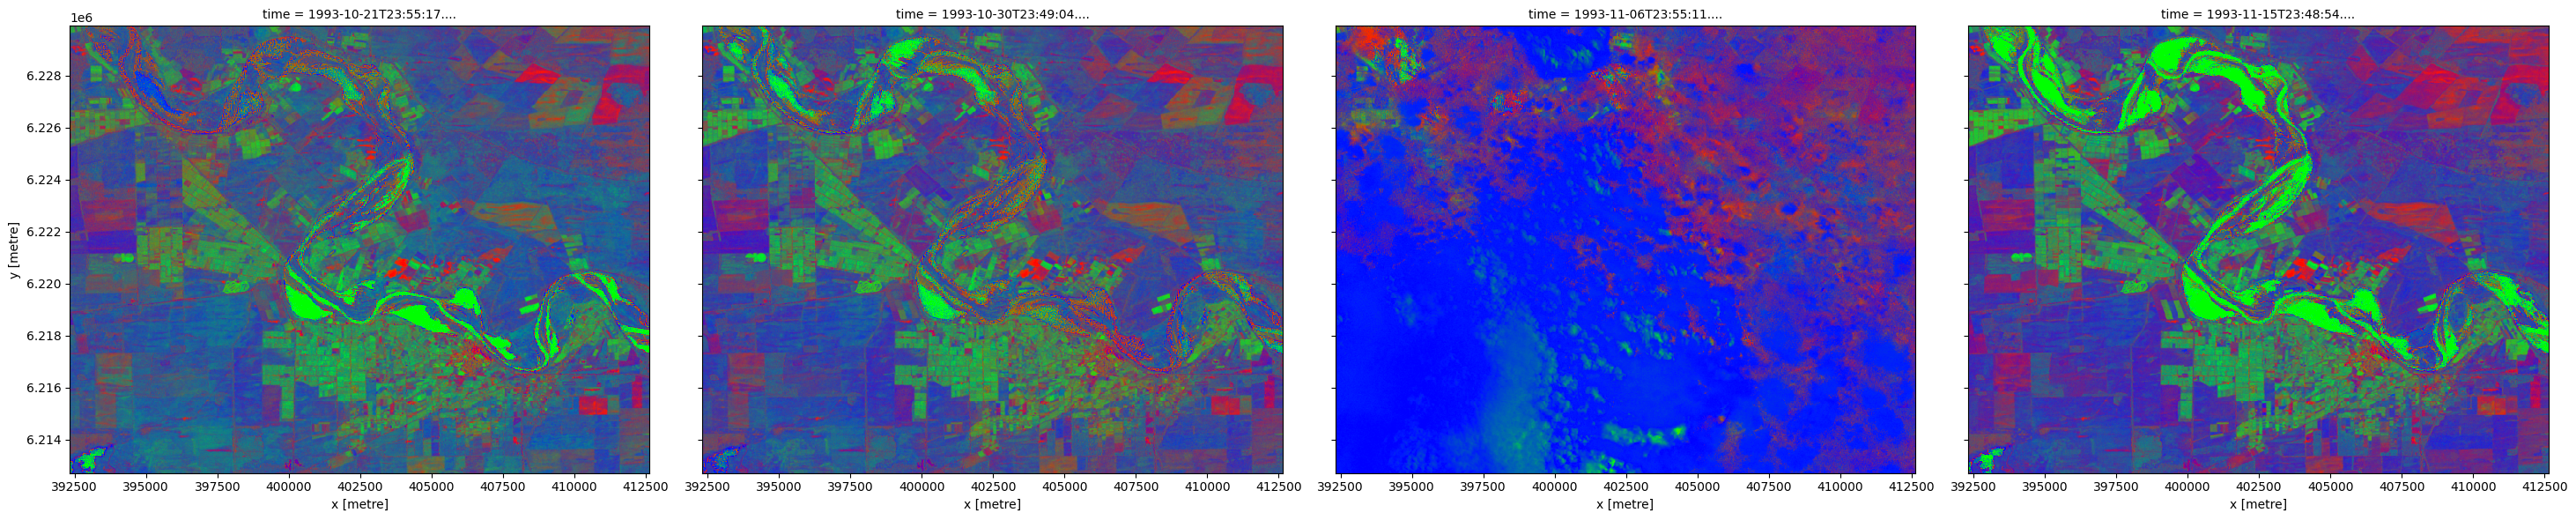

In [71]:
# Plot DEA Fractional Cover data as a false colour RGB image
rgb(fc, bands=['bs', 'pv', 'npv'], col='time')

We can also visualise the 'unmixing error' (`ue`) for each of our DEA Fractional Cover observations. 
High unmixing error values (bright colours below) represent areas of higher model uncertainty (e.g. areas of water, cloud, cloud shadow or soil types/colours that were not included in the model training data). 
This data can be useful for removing uncertain pixels from an analysis.

In this example, wet pixels associated with a river have relatively high unmixing errors.

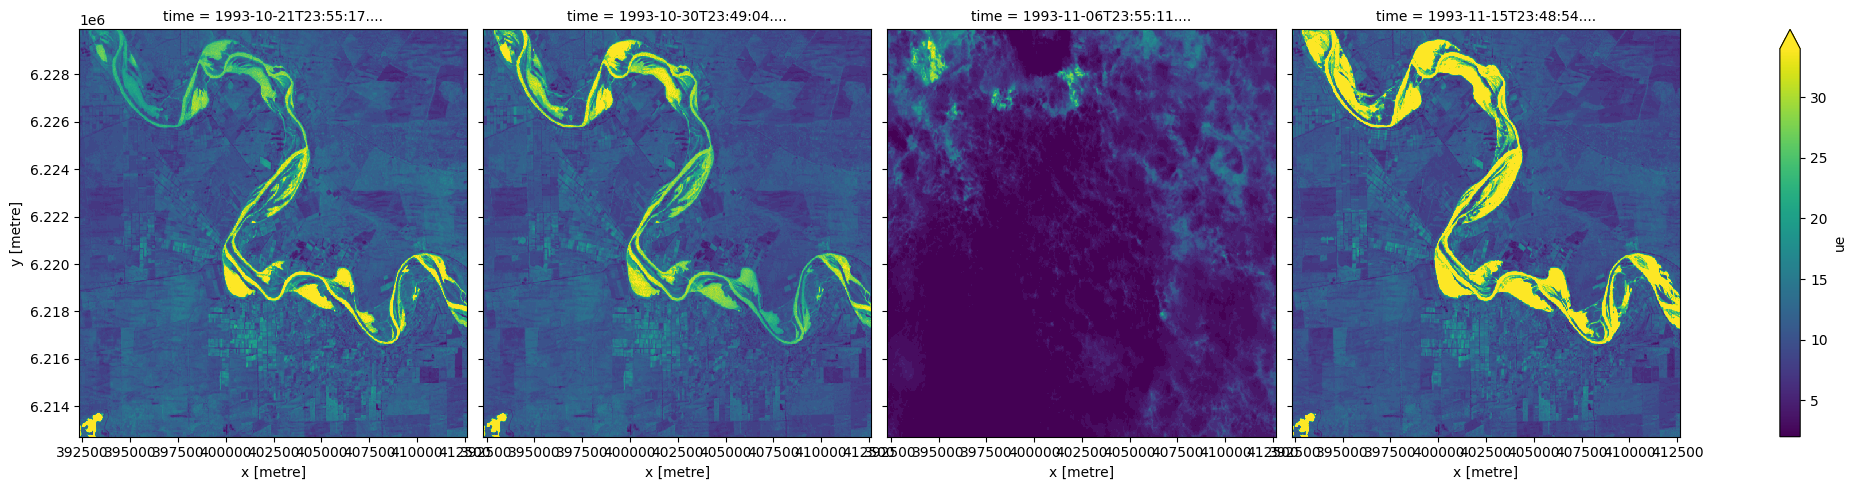

In [72]:
# Plot unmixing error using `robust=True` to drop outliers and improve contrast
fc.ue.plot(col='time', robust=True, size=5)

<div class="alert alert-info">
    
**Note:** For more technical information about the accuracy and limitations of DEA Fractional Cover, refer to the Details tab of the official [Geoscience Australia DEA Fractional Cover product description](https://knowledge.dea.ga.gov.au/data/product/dea-fractional-cover-landsat).
    
</div>

## Advanced: Tracking changes in vegetation cover and bare soil over time
The following section will demonstrate a simple analysis workflow based on DEA Fractional Cover. 
In this example, we will process our loaded FC data so that we can consistently track the changing proportions of green vegetation, brown vegetation and bare soil over time.

### Setting nodata for the Fractional Cover product
Before we start our analysis, we need to make sure that pixels containing `nodata` are set to `NaN` so that they are correctly handled in future steps. 
Earlier, we used `dea_stac_cfg` to get the metadata, including the encoded nodata value, for the Fractional Cover product. 
Each band has its nodata value listed as an attribute, so we can access each band, check the nodata value, and replace this value with `NaN`.

In [73]:
# For each band, replace all nodata values with `NaN` and also update the nodata attribute
for var in fc.data_vars:
    # Get the nodata value for the band
    nodata = fc[var].attrs.get('nodata')
    # replace nodata value with NaN
    fc[var] = fc[var].where(fc[var] != nodata)
    # update the nodata attribute to NaN
    fc[var].attrs['nodata'] = np.nan

### Applying a cloud and water mask
In the images we plotted earlier, you may have noticed the third panel is affected by cloud. 
This can cause the fractional cover algorithm to produce misleading results, as clouds are mis-identified as `NPV` (non-photosynthetic vegetation). 
FC will also produce poor results over water, with wet pixels being incorrectly classified as `PV` (green vegetation). This can be seen in the fourth panel above.

To track FC reliably over time, we need to remove these potentially inaccurate pixels. 
We can do this by loading data from the [DEA Water Observations](DEA_Water_Observations.ipynb) product that identifies wet and unclear pixels (e.g. cloud or cloud shadow) in the landscape.



#### Loading WO data
We will repeat the steps for loading the Fractional Cover product for the Water Observations product, including using `dea_stac_cfg` to load the metadata we will need for the bit field data.


In [74]:
# Search the STAC catalog for Water Observations using the same query parameters as FC
query_wo = catalog.search(
    bbox=bbox,
    collections="ga_ls_wo_3",
    datetime="1993-10-15/1993-11-20")

# Get the metadata for DEA Water Observations
wo_config = dea_stac_cfg(products="ga_ls_wo_3")

# Convert the retrieved items to a list
items_wo = list(query_wo.items())
print(f"Found: {len(items_wo)} STAC items.")

Found: 8 STAC items.


In [75]:
# Load DEA Water Observations data
wo = odc.stac.load(
    items_wo,
    like=fc,
    bands=["water"],
    stac_cfg=wo_config,
    groupby="solar_day"
)

### Adding flag definitions to Water Observations data

When loading Water Observations data via STAC, the bit flag definitions are not automatically included in the dataset attributes. 
These definitions are essential for correctly interpreting the bit-encoded water classification values.

To add this metadata, we can retrieve the product definition YAML file directly from DEA's product catalog and manually add the flag definitions and nodata value to our Water Observations dataset.

#### Understanding Water Observations bit flags
DEA Water Observations data are stored as a bit field. This is a binary number, where each digit of the number is independantly set based on the presence (1) or absence (0) of an attribute (water, cloud, cloud shadow etc). 
In this way, a single decimal value for each pixel can provide information about a variety of features of that pixel. 

Below is a breakdown of which bits represent which features, along with the decimal value associated with that bit being set to true.

| Attribute | Bit / position   | Decimal value | Description |
|------|------|----|----|
| No data | 0:   `-------0` or `-------1` | 1| No data |
| Non contiguous | 1:   `------0-` or `------1-` | 2 | At least one EO band is missing or saturated |
| Low solar angle | 2:   `-----0--` or `-----1--` | 4 | Low solar incidence angle |
| Terrain shadow | 3:   `----0---` or `----1---` | 8 | Terrain shadow |
| High slope | 4:   `---0----` or `---1----` | 16 | High slope |
| Cloud shadow | 5:   `--0-----` or `--1-----` | 32 | Cloud shadow |
| Cloud | 6:   `-0------` or `-1------` | 64 | Cloudy |
| Water observed | 7:   `0-------` or `1-------` | 128 | Classified as water by the decision tree |


Any combinations of flags can be combined to create a unique decimal value. 
For example, a value of 136 indicates that water (128) AND terrain shadow / low solar angle (8) were observed for the pixel (i.e. 128 + 8 = 136).
A value of 144 would indicate water (128) AND high slope (16) were observed (128 + 16 = 144).


<div class="alert alert-info">
    
**Note:** For more details about loading Water Observations data, refer to the [Introduction to DEA Water Observations](DEA_Water_Observations.ipynb) notebook.
    
</div>

In [76]:
# Retrieve the Water Observations product YAML to get flag definitions
product_yaml_url = "https://explorer.dea.ga.gov.au/products/ga_ls_wo_3.odc-product.yaml"

with urllib.request.urlopen(product_yaml_url) as response:
    product_yaml = yaml.safe_load(response)

# Add the flag definitions and nodata value to the 'water' variable attributes
wo['water'].attrs['flags_definition'] = product_yaml['measurements'][0]['flags_definition']
wo['water'].attrs['nodata'] = product_yaml['measurements'][0]['nodata']

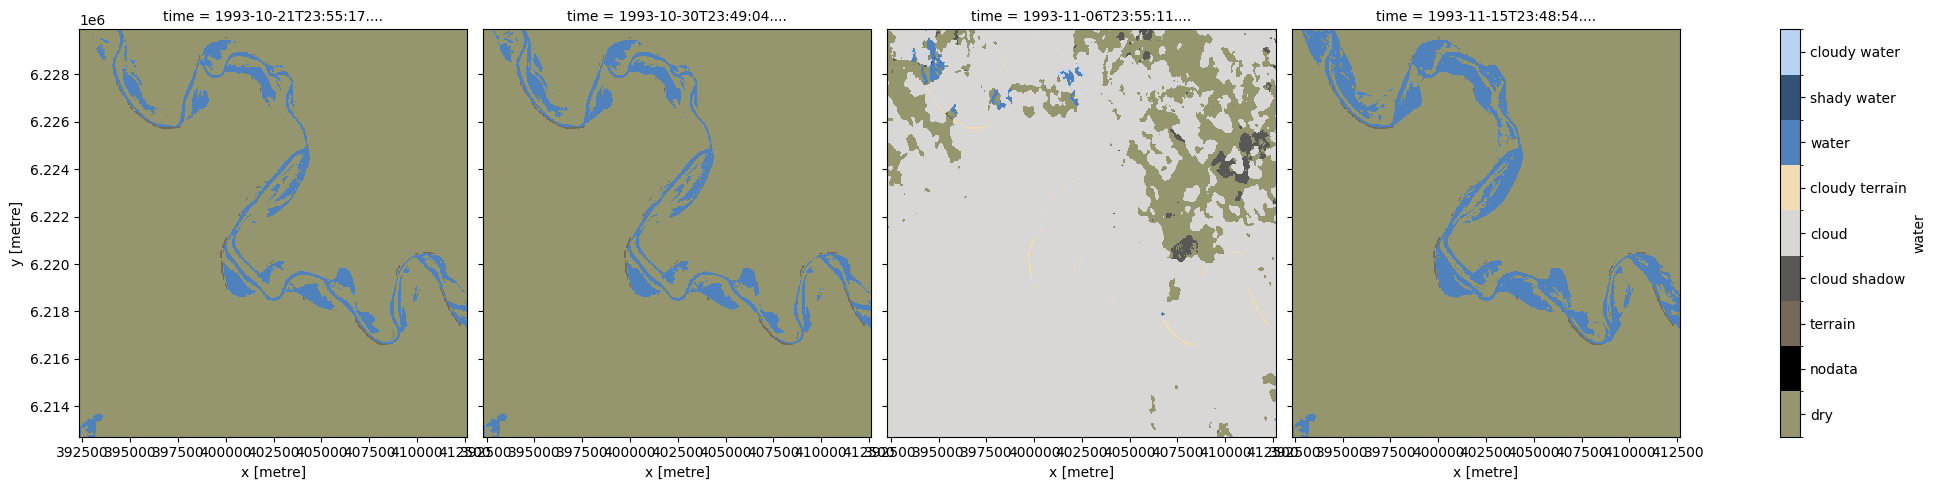

In [77]:
# Plot the Water Observations data to see water, cloud and shadow pixels
plot_wo(wo.water, col='time', size=5)

This plot shows that all images contain water pixels in and around the river, and the third image contains large amounts of cloud and cloud shadow. 
To remove these pixels, we will create a mask where `True` represents clear and dry pixels, and `False` represents wet, cloudy or shadowy pixels.


In [78]:
# Mask out water (128), cloud (64), cloud shadow (32), and nodata (1)
# Keep pixels where these bits are NOT set
wo_mask = (wo.water & (128 + 64 + 32 + 1)) == 0

Using this mask, we can now remove the wet and unclear pixels from our original DEA Fractional Cover data. 
Note that these pixels now appear white as they have been replaced with `NaN`.

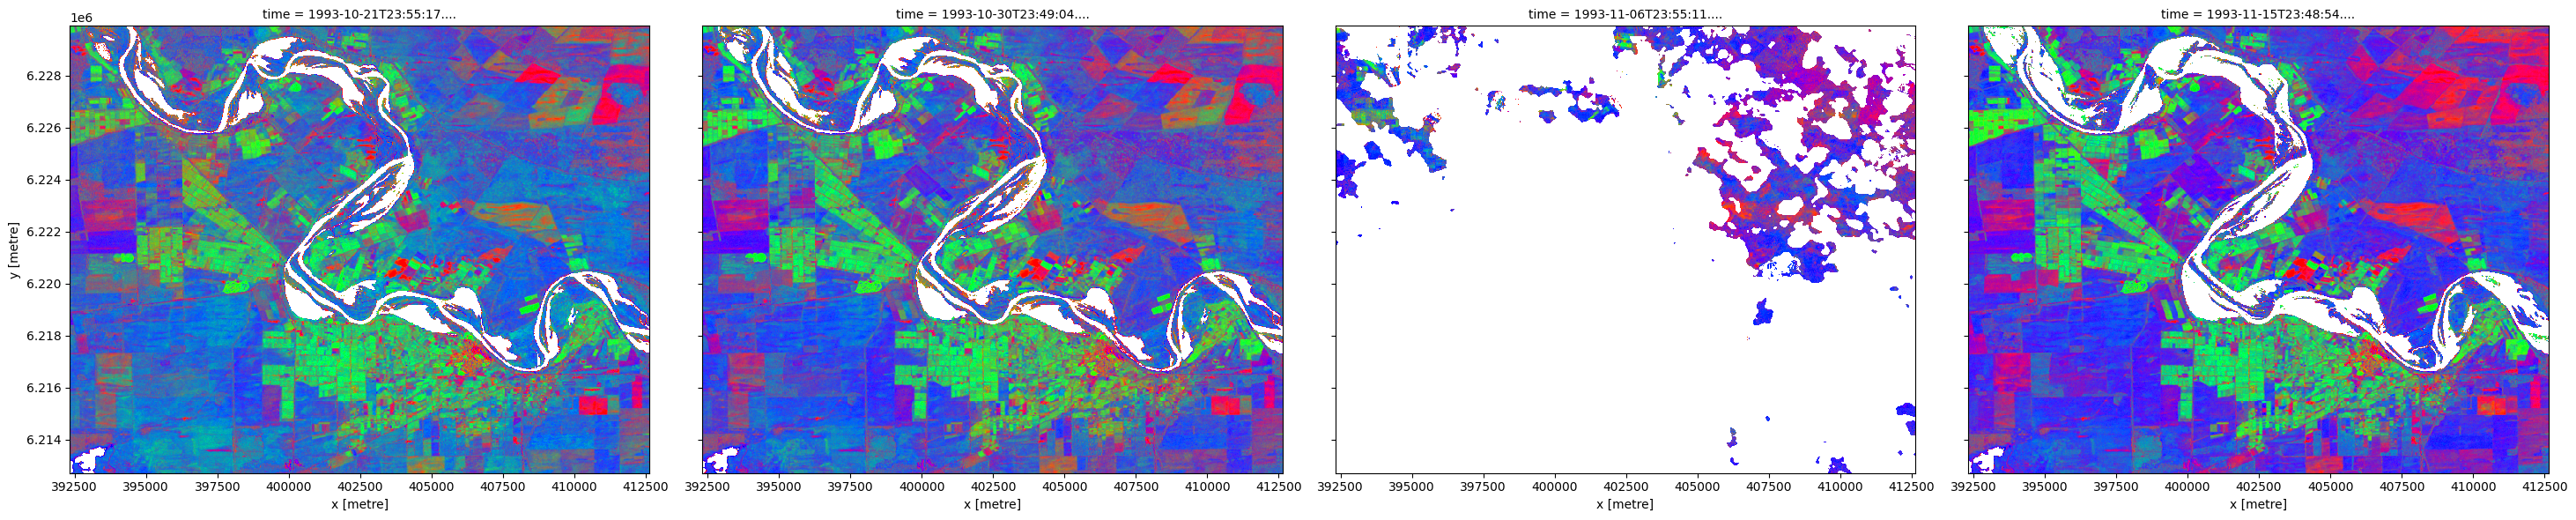

In [79]:
# Set any unclear or wet pixel to `NaN`
fc_masked = fc.where(wo_mask)

# Plot the masked fractional cover data
rgb(fc_masked, bands=['bs', 'pv', 'npv'], col='time')

### Dropping poorly observed scenes
In the image above, we can see that the third observation was mostly obscured by cloud, leaving very little usable data. 
So that this doesn't lead to unrepresentative statistics, we can keep only observations that had (for example) less than 50% nodata pixels.

In [80]:
# Calculate the percent of nodata pixels in each observation
percent_nodata = fc_masked.pv.isnull().mean(dim=['x', 'y'])

# Use this to filter to observations with less than 50% nodata
fc_masked = fc_masked.sel(time=percent_nodata < 0.5)

# The data now contains only three observations
fc_masked

<xarray.Dataset> Size: 19MB
Dimensions:      (time: 3, y: 573, x: 677)
Coordinates:
  * time         (time) datetime64[ns] 24B 1993-10-21T23:55:17.672013 ... 199...
  * y            (y) float64 5kB 6.23e+06 6.23e+06 ... 6.213e+06 6.213e+06
  * x            (x) float64 5kB 3.923e+05 3.924e+05 ... 4.126e+05 4.126e+05
    spatial_ref  int32 4B 32754
Data variables:
    pv           (time, y, x) float32 5MB 52.0 51.0 53.0 47.0 ... 30.0 32.0 23.0
    npv          (time, y, x) float32 5MB 27.0 25.0 31.0 35.0 ... 48.0 52.0 51.0
    bs           (time, y, x) float32 5MB 20.0 22.0 14.0 17.0 ... 21.0 15.0 25.0
    ue           (time, y, x) float32 5MB 12.0 13.0 11.0 10.0 ... 13.0 12.0 11.0

### Calculating average fractional cover over time
Now that our FC data has had nodata values and cloud, shadow and water pixels set to `NaN` and we have dropped unrepresentative observations, we can reliably track how average proportions of green and brown vegetation and bare soil have changed over time across our entire study area. 
We can then plot this as a line chart, showing that green vegetation (`pv`) has consistently decreased over time at this location, and brown vegetation (`npv`) and bare soil (`bs`) have increased.

Text(0, 0.5, 'Percent cover (%)')

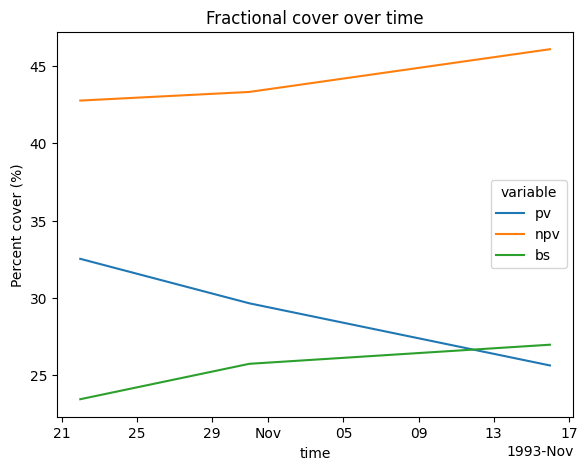

In [81]:
# Calculate average fractional cover for `bs`, `pv` and `npv` over time
fc_through_time = fc_masked[['pv', 'npv', 'bs']].mean(dim=['x', 'y'])

# Plot the changing proportions as a line graph
fc_through_time.to_array().plot.line(hue='variable', size=5)
plt.title('Fractional cover over time')
plt.ylabel('Percent cover (%)')

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last tested:**


In [82]:
from datetime import datetime
datetime.today().strftime('%Y-%m-%d')

'2025-12-11'